<a href="https://colab.research.google.com/github/juanitarhea/ai-drone-swarm/blob/main/M4_SupplyOpt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install deap numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 2.0 MB/s eta 0:00:00


In [ ]:
import random
from deap import base, creator, tools, algorithms

# Define locations (disaster supply points)
locations = [(0,0), (2,3), (5,1), (7,4), (3,6)]

# GA will find the shortest delivery route
# DEAP library handles the evolutionary algorithm for you

In [ ]:
import torch
from torch_geometric.data import Data

# 4 drones (nodes), each with 2 features (x, y position)
x = torch.tensor([
    [0, 0],
    [1, 0],
    [0, 1],
    [1, 1]
], dtype=torch.float)

# Connections between drones (edges)
edge_index = torch.tensor([
    [0, 1, 2, 3],
    [1, 0, 3, 2]
], dtype=torch.long)

data = Data(x=x, edge_index=edge_index)

print(data)

Best route: [1, 4, 3, 2, 0]
Shortest distance: 19.94453567968872


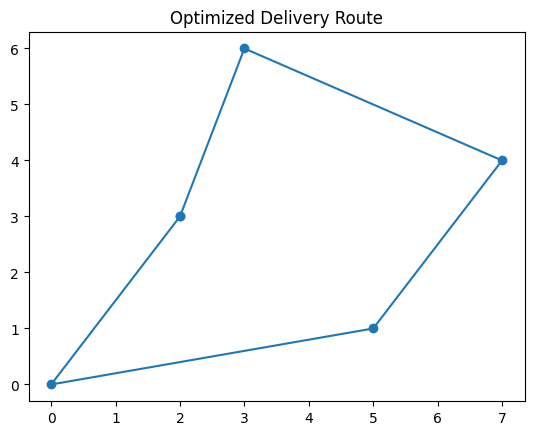

In [ ]:
import random
import numpy as np
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt

# Locations (x, y)
locations = [(0,0), (2,3), (5,1), (7,4), (3,6)]

# Distance function
def distance(a, b):
    return np.linalg.norm(np.array(a) - np.array(b))

# Total route distance (fitness)
def route_distance(individual):
    total = 0
    for i in range(len(individual) - 1):
        total += distance(locations[individual[i]], locations[individual[i+1]])
    total += distance(locations[individual[-1]], locations[individual[0]])  # return to start
    return (total,)  # must return tuple

# GA setup
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

# Individual = random permutation of location indices
toolbox.register("indices", random.sample, range(len(locations)), len(locations))
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.indices)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Operators
toolbox.register("evaluate", route_distance)
toolbox.register("mate", tools.cxOrdered)
toolbox.register("mutate", tools.mutShuffleIndexes, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

# Run GA
population = toolbox.population(n=100)

result, log = algorithms.eaSimple(
    population,
    toolbox,
    cxpb=0.7,
    mutpb=0.2,
    ngen=50,
    verbose=False
)

# Best solution
best = tools.selBest(result, k=1)[0]
print("Best route:", best)
print("Shortest distance:", route_distance(best)[0])

# Plot route
route = best + [best[0]]
x = [locations[i][0] for i in route]
y = [locations[i][1] for i in route]

plt.plot(x, y, marker='o')
plt.title("Optimized Delivery Route")
plt.show()

In [ ]:
def greedy_route():
    unvisited = list(range(len(locations)))
    route = [unvisited.pop(0)]

    while unvisited:
        last = route[-1]
        next_city = min(unvisited, key=lambda x: distance(locations[last], locations[x]))
        route.append(next_city)
        unvisited.remove(next_city)

    return route

g = greedy_route()
print("Greedy distance:", route_distance(g)[0])

Greedy distance: 19.944535679688723


In [ ]:
import numpy as np
import random

# Locations
locations = [(0,0), (2,3), (5,1), (7,4), (3,6)]
n_locations = len(locations)

# Distance function
def distance(a, b):
    return np.linalg.norm(np.array(a) - np.array(b))

# Parameters
num_agents = 2
episodes = 500
alpha = 0.1
gamma = 0.9
epsilon = 0.2

# Q-tables (one per agent)
Q_tables = [np.zeros((n_locations, n_locations)) for _ in range(num_agents)]

# Training
for ep in range(episodes):
    visited = set()
    agent_positions = [random.randint(0, n_locations-1) for _ in range(num_agents)]

    for step in range(n_locations):
        for i in range(num_agents):
            state = agent_positions[i]

            # Available actions = unvisited locations
            actions = [a for a in range(n_locations) if a not in visited]
            if not actions:
                continue

            # Epsilon-greedy
            if random.random() < epsilon:
                action = random.choice(actions)
            else:
                action = max(actions, key=lambda x: Q_tables[i][state][x])

            # Reward = negative distance (we want shorter routes)
            reward = -distance(locations[state], locations[action])

            # Update Q-value
            Q_tables[i][state][action] += alpha * (
                reward + gamma * np.max(Q_tables[i][action]) - Q_tables[i][state][action]
            )

            agent_positions[i] = action
            visited.add(action)

# Testing (build routes)
routes = [[] for _ in range(num_agents)]
visited = set()

agent_positions = [0 for _ in range(num_agents)]

for step in range(n_locations):
    for i in range(num_agents):
        state = agent_positions[i]
        actions = [a for a in range(n_locations) if a not in visited]

        if not actions:
            continue

        action = max(actions, key=lambda x: Q_tables[i][state][x])
        routes[i].append(action)
        visited.add(action)
        agent_positions[i] = action

# Calculate total distance
def route_dist(route):
    if len(route) < 2:
        return 0
    return sum(distance(locations[route[i]], locations[route[i+1]]) for i in range(len(route)-1))

total = sum(route_dist(r) for r in routes)

print("Routes per agent:", routes)
print("Total distance (MARL):", total)

Routes per agent: [[0, 2, 3], [1, 4]]
Total distance (MARL): 11.866848449225154


In [ ]:
ga_distance = 19.944535679688720
greedy_distance = 19.944535679688723
marl_distance = 11.866848449225154

improvement = ((greedy_distance - marl_distance) / greedy_distance) * 100

print("=" * 50)
print("       SUPPLYOPT EVALUATION RESULTS")
print("=" * 50)
print(f"  Greedy Baseline Distance  : {greedy_distance:.4f} units")
print(f"  GA Optimised Distance     : {ga_distance:.4f} units")
print(f"  MARL Multi-Drone Distance : {marl_distance:.4f} units")
print(f"  Improvement over Greedy   : {improvement:.1f}%")
print(f"  Number of Drones          : 2")
print(f"  Number of Supply Points   : 5")
print(f"  MARL Episodes Trained     : 500")
print("=" * 50)
print(f"\n  Agent 1 Route: Depot → Point 0 → Point 2 → Point 3")
print(f"  Agent 2 Route: Depot → Point 1 → Point 4")

       SUPPLYOPT EVALUATION RESULTS
  Greedy Baseline Distance  : 19.9445 units
  GA Optimised Distance     : 19.9445 units
  MARL Multi-Drone Distance : 11.8668 units
  Improvement over Greedy   : 40.5%
  Number of Drones          : 2
  Number of Supply Points   : 5
  MARL Episodes Trained     : 500

  Agent 1 Route: Depot → Point 0 → Point 2 → Point 3
  Agent 2 Route: Depot → Point 1 → Point 4
